# Optimizers

Optimizers are the algorithms that update a model's parameters to minimize a function. Building on Gradient Descent, this notebook implements and visualizes more advanced optimizers, like Stochastic Gradient Descent (SGD), RMSprop, and Adam. Rather than fitting a dataset, we will watch each optimizer navigate a 3D surface, stepping from a shared starting point toward lower values of the function. This lets us compare how each optimizer behaves on the exact same problem.

Importing the libraries

In [1]:
# import numpy as np
import autograd.numpy as np
from autograd import grad
from autograd import elementwise_grad as egrad

%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from celluloid import Camera
import scienceplots
from IPython.display import Image

np.random.seed(0)
plt.style.use(["science", "no-latex"])

## Training Dataset

Instead of a dataset, our optimizers will minimize a mathematical function. We will use the surface:

$z = x^2 - y^2$

This is a hyperbolic paraboloid, also known as a saddle. The surface curves upward along the $x$ axis and downward along the $y$ axis, creating a saddle point where the gradient is small in some directions. Saddle points are a classic challenge for optimizers: a naive optimizer can stall near the ridge, while adaptive optimizers escape more quickly. This makes the saddle a great way to compare optimizer behavior.

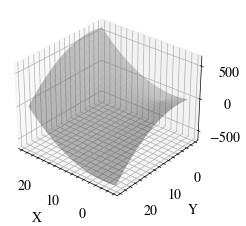

In [2]:
def surface_fn(X, Y):
    return X**2 - Y**2


def generate_function(dims, surface_fn):
    x = np.linspace(-5, 25, dims)
    y = np.linspace(-5, 25, dims)
    X, Y = np.meshgrid(x, y)
    Z = surface_fn(X, Y)

    return X, Y, Z


dims = 25
X, Y, Z = generate_function(dims, surface_fn)

# Visualize the Hyperbolic Paraboloid
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.view_init(30, 130)

ax.plot_surface(X, Y, Z, color="grey", alpha=0.4)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

## Optimizer Update Rules

Every optimizer in this notebook follows the same core idea as gradient descent: repeatedly step the parameters $\theta$ in the direction that decreases the function the most, which is the negative gradient. A single update step is:

$
\begin{align*}
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} f(\theta_t)
\end{align*}
$

where $\eta$ is the learning rate and $\nabla_{\theta} f(\theta_t)$ is the gradient of the function with respect to the parameters at step $t$. The optimizers below differ in how they use the gradient, such as accumulating past gradients (momentum) or scaling each parameter's step by a running estimate of its gradient magnitude (adaptive learning rates).

### Stochastic Gradient Descent (SGD)

SGD is the simplest optimizer. It takes a step directly proportional to the negative gradient, scaled by the learning rate:

$
\begin{align*}
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} f(\theta_t)
\end{align*}
$

SGD treats every parameter and every direction the same. Because the step depends only on the current gradient and a fixed learning rate, SGD can move very slowly in directions where the gradient is small, such as along the flat ridge of a saddle.

### RMSprop

RMSprop gives each parameter its own adaptive learning rate by keeping an exponentially decaying average of recent squared gradients, $s_t$:

$
\begin{align*}
s_{t+1} &= \beta s_t + (1 - \beta) (\nabla_{\theta} f(\theta_t))^2 \\
\theta_{t+1} &= \theta_t - \frac{\eta}{\sqrt{s_{t+1}} + \epsilon} \nabla_{\theta} f(\theta_t)
\end{align*}
$

Dividing by $\sqrt{s_{t+1}}$ shrinks the step for parameters with large, noisy gradients and enlarges it for parameters with small gradients. The small constant $\epsilon$ prevents division by zero. This adaptivity helps RMSprop make steady progress even where SGD stalls.

### Adam

Adam (Adaptive Moment Estimation) combines momentum with RMSprop's adaptive learning rates. It tracks an exponentially decaying average of the gradients (the first moment $m_t$) and of the squared gradients (the second moment $v_t$):

$
\begin{align*}
m_{t+1} &= \beta_1 m_t + (1 - \beta_1) \nabla_{\theta} f(\theta_t) \\
v_{t+1} &= \beta_2 v_t + (1 - \beta_2) (\nabla_{\theta} f(\theta_t))^2
\end{align*}
$

Because $m_t$ and $v_t$ start at zero, they are biased toward zero early in training, so Adam applies a bias correction:

$
\begin{align*}
\hat{m}_{t+1} = \frac{m_{t+1}}{1 - \beta_1^{t+1}}, \quad \hat{v}_{t+1} = \frac{v_{t+1}}{1 - \beta_2^{t+1}}
\end{align*}
$

The parameters are then updated using the corrected moments:

$
\begin{align*}
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_{t+1}} + \epsilon} \hat{m}_{t+1}
\end{align*}
$

Combining momentum and adaptive scaling makes Adam a robust default optimizer that often converges quickly across many problems.

## Surface Gradient

Each optimizer needs the gradient of the surface with respect to the current point $\theta = (x, y)$. For our surface $z = x^2 - y^2$, the partial derivatives are:

$
\begin{align*}
\frac{\partial z}{\partial x} = 2x, \quad \frac{\partial z}{\partial y} = -2y
\end{align*}
$

so the gradient is $\nabla z = (2x, -2y)$. The gradient grows with $|x|$ along the upward-curving axis and with $|y|$ along the downward-curving axis. This is the signal every optimizer below uses to decide its next step.

## Implementing the Optimizers

Let's implement each optimizer from scratch as a class with a `step` method that takes the current parameters and gradient and returns the updated parameters. The stateful optimizers (RMSprop and Adam) keep their running averages between steps.

In [3]:
def surface_gradient(pt):
    x, y = pt
    return np.array([2 * x, -2 * y])


class SGD:
    def __init__(self, learning_rate):
        self.learning_rate = learning_rate

    def step(self, params, gradient):
        return params - self.learning_rate * gradient


class RMSprop:
    def __init__(self, learning_rate, beta=0.99, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.beta = beta
        self.epsilon = epsilon
        self.s = 0

    def step(self, params, gradient):
        self.s = self.beta * self.s + (1 - self.beta) * gradient**2
        return params - self.learning_rate * gradient / (np.sqrt(self.s) + self.epsilon)


class Adam:
    def __init__(self, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = 0
        self.v = 0
        self.t = 0

    def step(self, params, gradient):
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradient
        self.v = self.beta2 * self.v + (1 - self.beta2) * gradient**2
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        return params - self.learning_rate * m_hat / (np.sqrt(v_hat) + self.epsilon)

## Graphing functions

Let's define helper functions to plot the graphs. `create_scatter_and_3d_plot` sets up two views: a 2D plot tracking each optimizer's $z$ value over the epochs, and a 3D plot showing each optimizer's current position on the surface. `show_epoch` controls how often a frame is captured for the animation, sampling frequently early in training and less often later.

In [4]:
def create_scatter_and_3d_plot():
    fig, ax = plt.subplots(1, 3, figsize=(16 / 9.0 * 4, 4 * 1))
    fig.suptitle("Optimizers")

    ylim = (-5, 25)
    zlim = (-650, 550)

    ax[0].set_xlabel("Epoch", fontweight="normal")
    ax[0].set_ylabel("Z", fontweight="normal")
    ax[0].set_title("Z Value")
    ax[0].set_ylim((-650, 450))

    ax[1].axis("off")
    ax[2].axis("off")

    ax[2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[2].set_xlabel("X")
    ax[2].set_ylabel("Y")
    ax[2].set_zlabel("Z")
    ax[2].set_title("Current Position")
    ax[2].view_init(30, 130)
    ax[2].set_xlim(ylim)
    ax[2].set_ylim(ylim)
    ax[2].set_zlim(zlim)

    camera = Camera(fig)
    return ax[0], ax[2], camera


def show_epoch(epoch):
    return (
        (epoch < 25 and epoch % 2 == 0)
        or (epoch < 50 and epoch % 5 == 0)
        or (epoch <= 100 and epoch % 15 == 0)
        or (epoch <= 500 and epoch % 45 == 0)
        or (epoch <= 1000 and epoch % 50 == 0)
        or epoch % 250 == 0
    )

## Training the Model

The `fit` function runs every optimizer in parallel from the same starting point. In each epoch it evaluates the surface, computes the gradient, and asks each optimizer for its next position, recording the trajectory so the optimizers can be animated side by side.

In [5]:
def fit(optimizers, surface_fn, X, Y, Z, initial_pt, epochs, output_filename, colors):
    optimizer_names = list(optimizers.keys())
    points = [initial_pt.copy() for _ in optimizers]

    z_idx = np.arange(1, epochs + 1)
    z_vals = [np.full(epochs, -1.0) for _ in range(len(optimizer_names))]

    z_ax, predictions_ax, camera = create_scatter_and_3d_plot()

    for idx in range(epochs):
        prediction_legends = []
        z_legends = []

        for opt_idx, optimizer in enumerate(optimizers.values()):
            pt = points[opt_idx]
            z = surface_fn(pt[0], pt[1])
            gradient = surface_gradient(pt)
            points[opt_idx] = optimizer.step(pt, gradient)

            if show_epoch(idx):
                z_clamped = np.maximum(-1000, z)

                prediction_legend = predictions_ax.scatter(
                    pt[0], pt[1], z_clamped, color=colors[opt_idx]
                )
                prediction_legends.append(prediction_legend)

                z_vals[opt_idx][idx] = z_clamped
                visible = z_vals[opt_idx] != -1
                z_legend = z_ax.plot(
                    z_idx[visible][: idx + 1],
                    z_vals[opt_idx][visible][: idx + 1],
                    color=colors[opt_idx],
                    alpha=0.5,
                )
                z_legends.append(z_legend[0])

        if show_epoch(idx):
            predictions_ax.plot_surface(X, Y, Z, color="grey", alpha=0.3)
            predictions_ax.legend(prediction_legends, optimizer_names, loc="upper right")
            z_ax.legend(z_legends, optimizer_names, loc="upper right")
            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")
    plt.show()

Let's train all three optimizers from the same starting point and compare them. We start near the saddle's ridge at $(20.75, 0.5)$, where the gradient along the $y$ axis is small. SGD, Adam, and RMSprop are each given the same learning rate, so the only difference is the update rule.

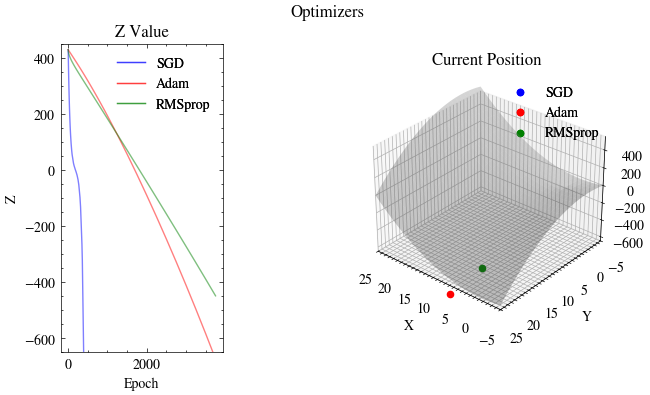

In [6]:
initial_pt = np.array([20.75, 0.5])

learning_rate = 0.005
epochs = 4000

optimizers = {
    "SGD": SGD(learning_rate),
    "Adam": Adam(learning_rate),
    "RMSprop": RMSprop(learning_rate),
}
colors = ["blue", "red", "green"]

output_filename = "optimizers.gif"
fit(optimizers, surface_fn, X, Y, Z, initial_pt, epochs, output_filename, colors)

## Output GIF

The animation below shows our from-scratch SGD, Adam, and RMSprop descending the saddle surface from the same starting point. The left plot tracks how quickly each optimizer drives the $z$ value down, while the right plot shows each optimizer's current position on the surface.

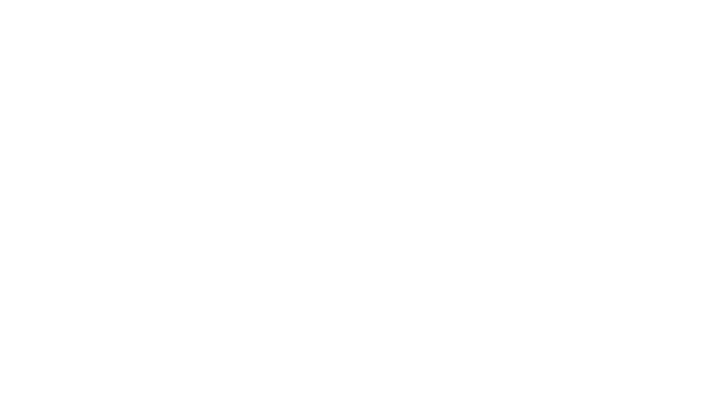

In [7]:
Image(filename=output_filename)

## PyTorch Implementation

Machine learning libraries, such as PyTorch, provide highly optimized implementations of these optimizers. We will use PyTorch to run the same three optimizers on the same surface and confirm our from-scratch results.

In [8]:
import torch
import torch.nn as nn

torch.manual_seed(0)

We represent the optimization problem as a small model whose only parameters are the coordinates of a point on the surface. The `forward` method evaluates the surface function at the current point, which is the value we want to minimize.

In [9]:
class TorchNet(nn.Module):
    def __init__(self, initial_pt):
        super(TorchNet, self).__init__()

        self.pts = torch.nn.Parameter(initial_pt)

    def forward(self, surface_fn):
        return surface_fn(self.pts[0], self.pts[1])

    def get_pts(self):
        return self.pts.detach().cpu().numpy()

The training function creates one model and one optimizer per optimizer type, all starting from the same initial point. In each epoch, it evaluates the surface at every optimizer's current point, backpropagates the gradient, and steps each optimizer.

In [10]:
def torch_fit(
    optimizer_types, surface_fn, X, Y, Z, epochs, learning_rate, output_filename, colors
):
    torch_models = []
    torch_optimizers = []
    optimizer_names = list(optimizer_types.keys())

    z_idx = np.arange(1, epochs + 1)
    z_vals = [np.full(epochs, -1) for _ in range(len(optimizer_names))]

    for optimizer in optimizer_types.values():
        torch_model = TorchNet(initial_pt_tensor.clone()).to(device)
        torch_optimizer = optimizer(torch_model.parameters(), lr=learning_rate)

        torch_models.append(torch_model)
        torch_optimizers.append(torch_optimizer)

    z_ax, predictions_ax1, camera1 = create_scatter_and_3d_plot()

    for idx in range(epochs):
        predictions_legends = []
        z_legends = []

        for torch_idx, (model, optimizer) in enumerate(
            zip(torch_models, torch_optimizers)
        ):
            loss = model(surface_fn)

            # optimizer
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if show_epoch(idx):
                loss_np = np.maximum(-1000, loss.detach().cpu().numpy())

                model_pts = model.get_pts()
                predictions_legends_idx = predictions_ax1.scatter(
                    model_pts[0], model_pts[1], loss_np, color=colors[torch_idx]
                )
                predictions_legends.append(predictions_legends_idx)

                z_vals[torch_idx][idx] = loss_np
                visible_mse = z_vals[torch_idx] != -1

                z_legends_idx = z_ax.plot(
                    z_idx[visible_mse][: idx + 1],
                    z_vals[torch_idx][visible_mse][: idx + 1],
                    color=colors[torch_idx],
                    alpha=0.5,
                )
                z_legends.append(z_legends_idx[0])

        if show_epoch(idx):
            predictions_ax1.plot_surface(X, Y, Z, color="grey", alpha=0.3)
            predictions_ax1.legend(
                predictions_legends, optimizer_names, loc="upper right"
            )
            z_ax.legend(z_legends, optimizer_names, loc="upper right")

            camera1.snap()

    animation1 = camera1.animate()
    animation1.save(output_filename, writer="pillow")
    plt.show()

## Training the Model with PyTorch

Let's run PyTorch's SGD, Adam, and RMSprop from the same starting point and learning rate we used for our from-scratch implementation.

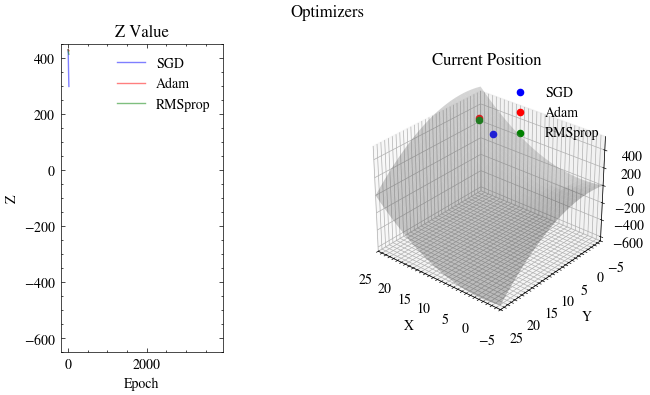

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

initial_pt = np.array([20.75, 0.5])
initial_pt_tensor = torch.tensor(initial_pt, device=device, dtype=torch.float32)

optimizer_types = {
    "SGD": torch.optim.SGD,
    "Adam": torch.optim.Adam,
    "RMSprop": torch.optim.RMSprop,
}
colors = ["blue", "red", "green"]

learning_rate = 0.005
epochs = 4000

output_filename_pytorch = "optimizers_pytorch.gif"
torch_fit(
    optimizer_types,
    surface_fn,
    X,
    Y,
    Z,
    epochs,
    learning_rate,
    output_filename_pytorch,
    colors,
)

## Output GIF with PyTorch

The PyTorch optimizers produce trajectories that match our from-scratch implementation, confirming our derivations of SGD, RMSprop, and Adam.

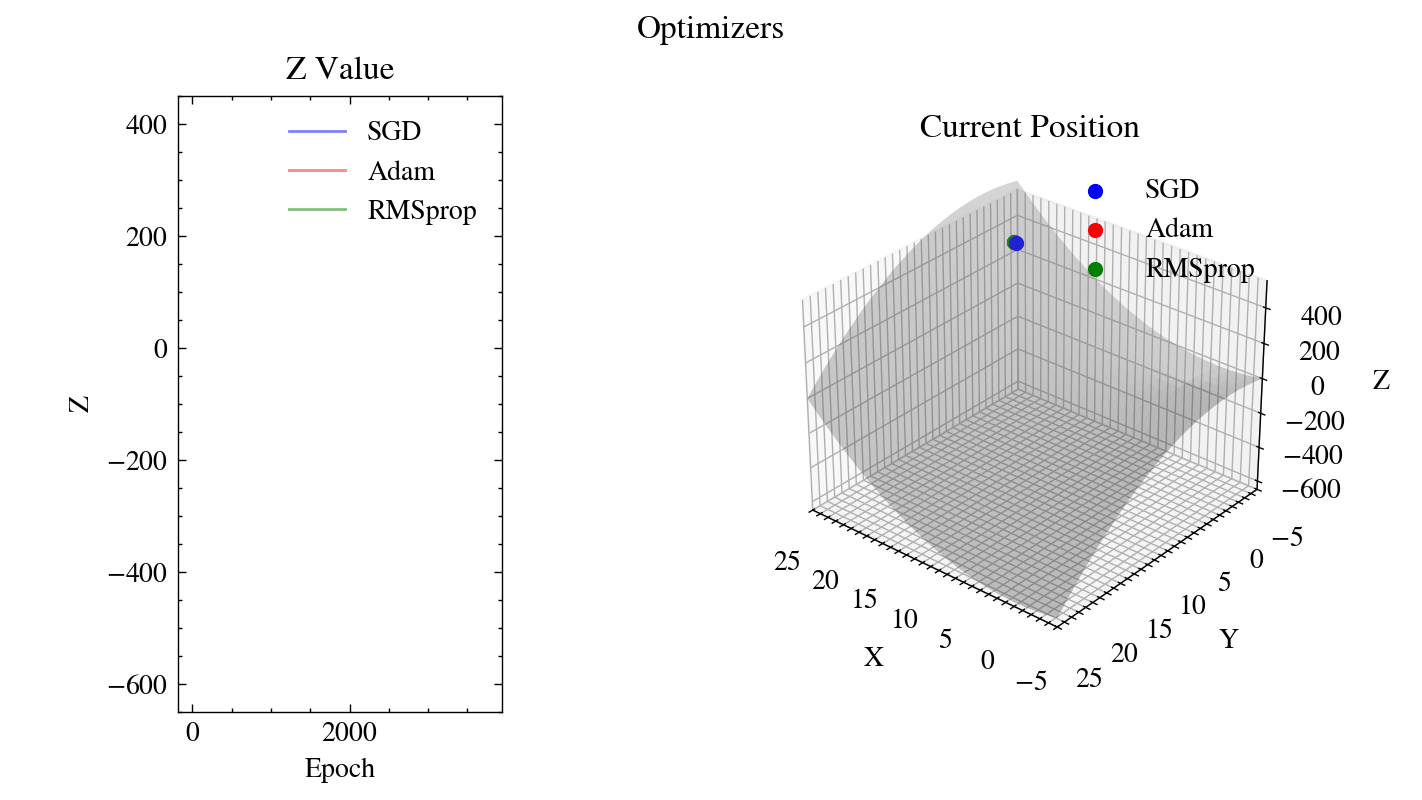

In [12]:
Image(filename=output_filename_pytorch)